In [1]:
from fetch_polarimetry import fetch_gpips, fetch_scupol_l1544
from bistro import run_validation
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# from astroquery.irsa import Irsa
# from astropy.coordinates import SkyCoord, Galactic
# import astropy.units as u

# gal = SkyCoord(l=45.6*u.deg, b=0.3*u.deg, frame=Galactic)
# icrs = gal.icrs

# Irsa.ROW_LIMIT = 5
# result = Irsa.query_region(icrs, catalog="gpipsdr4", spatial="Cone", radius=0.1*u.deg)
# print(result.colnames)

In [2]:
run_validation()

BISTRO Polarimetry Validation

-------------------------------------------------------
Target: rho Oph A  (catalog: J/ApJ/908/10)
  RA=246.6125, Dec=-24.4000, radius=8.0'
  !! No tables returned from VizieR.

-------------------------------------------------------
Target: OMC-1  (catalog: J/ApJ/913/128)
  RA=83.8208, Dec=-5.3750, radius=8.0'
  !! No tables returned from VizieR.

-------------------------------------------------------
Target: L1689  (catalog: J/ApJ/877/88)
  RA=248.1208, Dec=-24.4811, radius=8.0'
  !! No tables returned from VizieR.

-------------------------------------------------------
Target: IC 5146  (catalog: J/ApJ/876/42)
  RA=328.3500, Dec=47.2667, radius=10.0'
  !! No tables returned from VizieR.

-------------------------------------------------------
Target: L1544  (catalog: J/ApJS/182/143)
  RA=76.0717, Dec=25.1786, radius=5.0'
  Tables returned: ['J/ApJS/182/143/target', 'J/ApJS/182/143/table6']
  Found pol table: 20 rows, columns: ['_r', 'recno', 'ID', 'n_

name,geometry,M_A,M_A_ref,N_vectors,skewness,catalog
str5,str9,float64,str27,int64,float64,str14
L1544,hourglass,0.5,Ward-Thompson+2000 (SCUPOL),19,1.316314142351649,J/ApJS/182/143


In [2]:
gpips  = fetch_gpips()           # astropy Table, GPIPS stars
scupol = fetch_scupol_l1544()    # astropy Table, SCUPOL vectors


Fetching GPIPS DR4 polarimetry for GRSMC 45.60+0.30
Applying Marchwinski+2012 selection criteria
  Cloud centre: l=45.6, b=0.3  ->  RA=288.4405, Dec=11.3944
  Initial cone search radius: 0.6 deg
  Querying IRSA catalog: gpipsdr4 ...
  Retrieved 199816 stars in cone before any cuts.
  Cut 1 -- 2MASS matched:               73612 stars
  Cut 2 -- H_mag < 12.5:                13041 stars
  Cut 3 -- SP < 2%:                     11506 stars
  Cut 4 -- P/SP >= 2:                    4239 stars
  Cut 5 -- Cloud spatial boundary:       4161 stars
  Cut 6 -- Cloud 2 exclusion zone:       3713 stars

  Final sample (all cuts):               3713 stars
  (Marchwinski+2012 reported 2684 stars)

  Summary (Marchwinski+2012 sample):
    N stars          = 3713
    Mean   p         = 2.05 %  (paper: 1.8 +/- 0.6 %)
    Median p         = 1.82 %
    Max    p         = 11.23 %
    Circular mean GPA= 69.0 deg  (paper: ~75-85 deg)
    Circular std  GPA= 29.6 deg  (paper: 15 +/- 2 deg)

  Saved FITS: ./pol_

pa_deg  -- min:0.0 max:180.0 mean:78.7
gpa_deg -- min:0.1 max:179.9 mean:73.8


In [4]:
p_gpips  = gpips["p"]       # debiased polarization %
pa_gpips = gpips["pa_deg"]  # position angle, degrees E of N
sp_gpips = gpips["sp"]      # uncertainty in p
q_gpips  = gpips["q"]       # Stokes Q / I
u_gpips  = gpips["u"]       # Stokes U / I
ra_gpips = gpips["ra"]
dec_gpips = gpips["dec"]

In [5]:
p_scupol  = scupol["Pol"]    # polarization %
pa_scupol = scupol["theta"]  # position angle, degrees E of N
sp_scupol = scupol["e_Pol"]  # uncertainty in Pol
i_scupol  = scupol["Int"]    # total intensity
ra_scupol = scupol["RAJ2000"]
dec_scupol = scupol["DEJ2000"]

In [6]:
import numpy as np
p_gpips  = np.array(gpips["p"])
pa_gpips = np.array(gpips["pa_deg"])
p_scupol = np.array(scupol["Pol"])
pa_scupol = np.array(scupol["theta"])

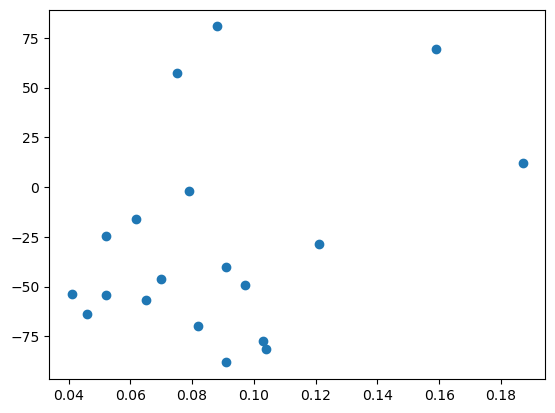

In [7]:
plt.plot(p_scupol/100, pa_scupol, 'o', label='SCUPOL')

(array([ 24., 107., 164., 206., 205., 233., 225., 224., 184., 204., 212.,
        180., 173., 142., 157., 128., 112., 116., 101.,  80.,  70.,  73.,
         61.,  57.,  51.,  44.,  29.,  20.,  20.,  17.,  17.,  10.,   7.,
         11.,   9.,   2.,   5.,   2.,   6.,   3.,   4.,   2.,   2.,   3.,
          2.,   1.,   2.,   1.,   2.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,
          0.,   0.,   0.,   2.]),
 array([0.0018    , 0.00337814, 0.00495629, 0.00653443, 0.00811257,
        0.00969071, 0.01126886, 0.012847  , 0.01442514, 0.01600329,
        0.01758143, 0.01915957, 0.02073771, 0.02231586, 0.023894  ,
        0.02547214, 0.02705029, 0.02862843, 0.03020657, 0.03178471,
        0.03336286, 0.034941  , 0.03651914, 0.03809729, 0.03967543,
        0.04125357, 0.04283171, 0.04440986, 0.045988  , 0.04756614,
        0.04914429, 0.05072243, 0.05230057, 0.05387871, 0.05545686,
        0.057035  , 0.05861314, 0.06019129, 0.

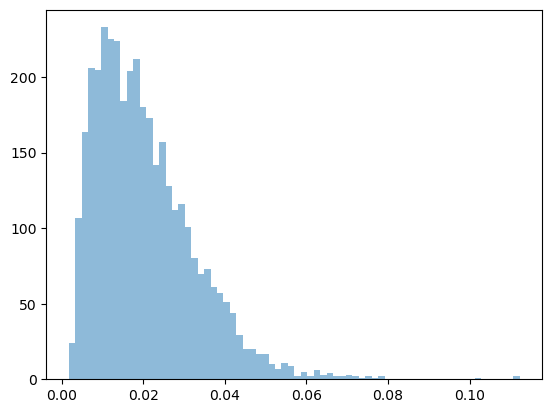

In [8]:
plt.hist(p_gpips/100., bins=70, alpha=0.5, label='GPIPS')


(array([145., 135., 149., 131., 145., 135., 149., 143., 137., 109., 101.,
         97.,  68.,  65.,  56.,  51.,  46.,  35.,  25.,  23.,  16.,  24.,
         20.,  18.,  16.,  19.,  21.,  16.,  15.,  21.,  26.,  16.,  18.,
         18.,  13.,  18.,  10.,   8.,  10.,   9.,   8.,   7.,   5.,  13.,
          7.,  11.,   9.,   8.,  14.,  10.,   9.,  16.,  22.,  21.,  24.,
         25.,  34.,  31.,  57.,  64.,  65.,  63., 110.,  93., 106., 105.,
        115., 126., 117., 141.]),
 array([1.70000000e-02, 2.58817351e+00, 5.15934701e+00, 7.73052052e+00,
        1.03016940e+01, 1.28728675e+01, 1.54440410e+01, 1.80152146e+01,
        2.05863881e+01, 2.31575616e+01, 2.57287351e+01, 2.82999086e+01,
        3.08710821e+01, 3.34422556e+01, 3.60134291e+01, 3.85846026e+01,
        4.11557761e+01, 4.37269496e+01, 4.62981231e+01, 4.88692966e+01,
        5.14404701e+01, 5.40116437e+01, 5.65828172e+01, 5.91539907e+01,
        6.17251642e+01, 6.42963377e+01, 6.68675112e+01, 6.94386847e+01,
        7.20098582

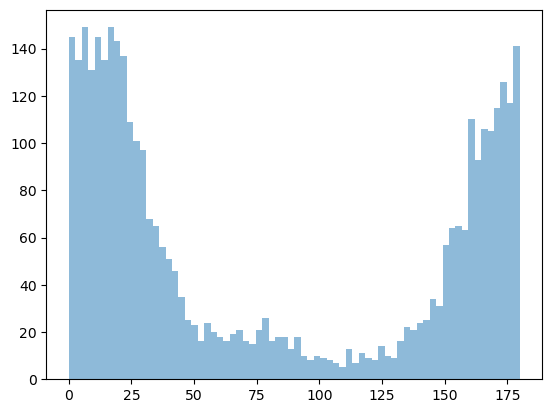

In [9]:
plt.hist(pa_gpips, bins=70, alpha=0.5, label='GPIPS PA')